# 01 — Exploratory Data Analysis

Malicious URL Detection — Final Year Project

This notebook explores the cleaned, binary-labeled URL dataset (Safe / Malicious)
after preprocessing, and inspects the 25 lexical features engineered in
`src/feature_engineering.py`.

All EDA figures are generated by `src/visualization.py` and saved to
`results/figures/`; this notebook re-displays them inline for convenience,
plus surfaces the underlying data at each stage.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Image, display

from src.preprocessing import load_raw_dataset, clean_and_encode, stratified_split
from src.feature_engineering import build_feature_matrix, FEATURE_NAMES
from src import visualization as viz

pd.set_option("display.max_columns", 30)

## Load the raw dataset

In [2]:
raw_df = load_raw_dataset()
print(f"Raw shape: {raw_df.shape}")
raw_df.head()

2026-08-07 10:15:43 | INFO     | src.preprocessing | Loading raw dataset from /home/claude/malicious_url_detector/data/raw/malicious_urls_dataset.csv


2026-08-07 10:15:43 | INFO     | src.preprocessing | Loaded 2500 raw rows


Raw shape: (2500, 2)


,url,type
0,http://account-344.suspicious-site1.tk/account...,phishing
1,http://github.com/home,benign
2,http://example.com,benign
3,http://wikipedia.org/articles/1056,benign
4,http://wikipedia.org,benign


## Clean and binary-encode labels

`benign -> Safe (0)`; `phishing`, `malware`, `defacement` -> `Malicious (1)`.
Duplicates, missing URLs, and any unrecognized label values are removed
(see `src/preprocessing.py` docstring for why each step is ordered as it is).

In [3]:
clean_df, report = clean_and_encode(raw_df)
print(report.to_dict())
clean_df.head()

2026-08-07 10:15:43 | INFO     | src.preprocessing | Cleaning complete: 2500 -> 1647 rows (removed 0 unmapped-label, 0 missing-URL, 853 duplicate). Class balance: {'Malicious': 1000, 'Safe': 647}


{'raw_row_count': 2500, 'duplicate_rows_removed': 853, 'missing_value_rows_removed': 0, 'unmapped_label_rows_removed': 0, 'final_row_count': 1647, 'class_balance': {'Malicious': 1000, 'Safe': 647}, 'train_row_count': 0, 'test_row_count': 0}


,url,label
0,http://account-344.suspicious-site1.tk/account...,1
1,http://github.com/home,0
2,http://example.com,0
3,http://wikipedia.org/articles/1056,0
4,http://wikipedia.org,0


## Build the full feature matrix

For EDA purposes we build features on the entire cleaned dataset (before the
train/test split), so plots reflect the full data distribution. Training itself
correctly builds features separately per split — see `src/train.py`.

In [4]:
feature_df = build_feature_matrix(clean_df, show_progress=True)
print(f"Feature matrix shape: {feature_df.shape}")
feature_df.head()

2026-08-07 10:15:43 | INFO     | src.feature_engineering | Extracting 25 lexical features for 1647 URLs


Extracting features:   0%|          | 0/1647 [00:00<?, ?it/s]

Extracting features:   0%|          | 1/1647 [00:00<03:47,  7.23it/s]

Extracting features:  91%|█████████ | 1496/1647 [00:00<00:00, 7598.45it/s]

Extracting features: 100%|██████████| 1647/1647 [00:00<00:00, 6554.36it/s]

2026-08-07 10:15:43 | INFO     | src.feature_engineering | Feature matrix built: shape=(1647, 26)


Feature matrix shape: (1647, 26)


,url_length,domain_length,num_dots,num_digits,num_hyphens,num_slashes,num_question_marks,num_equal_signs,num_ampersands,num_underscores,num_percent_signs,num_at_symbols,num_tildes,num_commas,num_semicolons,num_asterisks,num_colons,num_double_slashes,has_https,has_ip_address,num_subdomains,shannon_entropy,num_suspicious_keywords,path_length,query_length,label
0,66,19,2,10,2,3,1,2,1,0,0,0,0,0,0,0,1,0,0,0,1,4.321810,3,8,19,1
1,22,10,1,0,0,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,3.629220,0,5,0,0
2,18,11,1,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,3.614369,0,0,0,0
3,34,13,1,4,0,4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,4.241731,0,14,0,0
4,20,13,1,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,3.784184,0,0,0,0


## Class distribution

2026-08-07 10:15:43 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/class_distribution.png


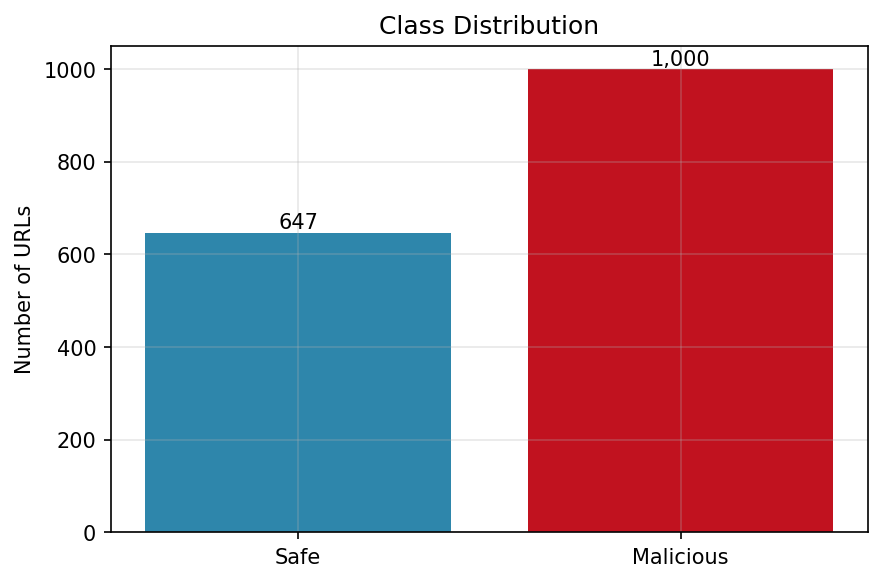

label
Malicious    0.607165
Safe         0.392835
Name: proportion, dtype: float64

In [5]:
path = viz.plot_class_distribution(feature_df)
display(Image(filename=path))
feature_df["label"].value_counts(normalize=True).rename({0: "Safe", 1: "Malicious"})

## URL length distribution by class

2026-08-07 10:15:44 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/url_length_histogram.png


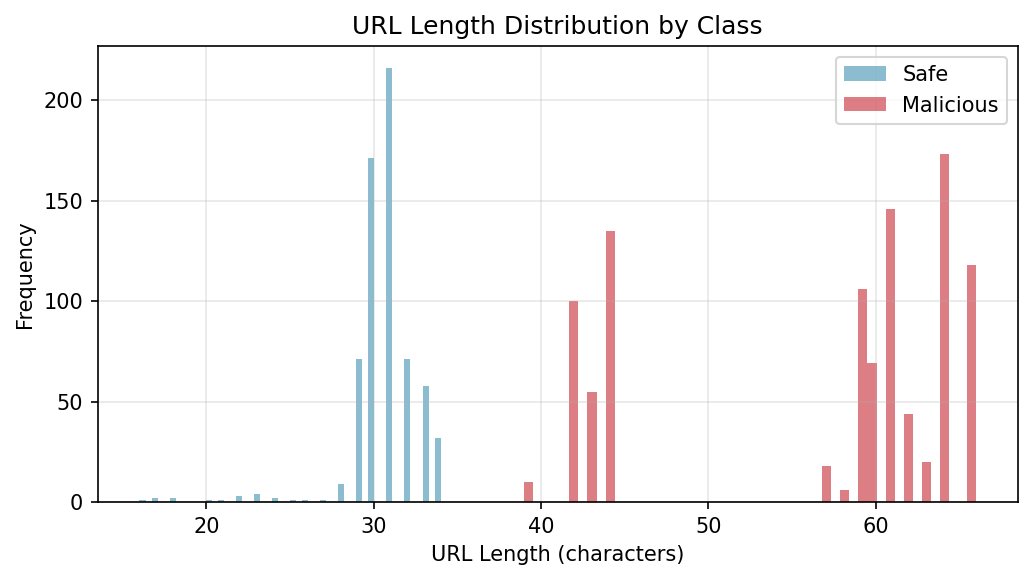

In [6]:
path = viz.plot_url_length_histogram(feature_df)
display(Image(filename=path))

## Missing values check

2026-08-07 10:15:44 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/missing_values.png


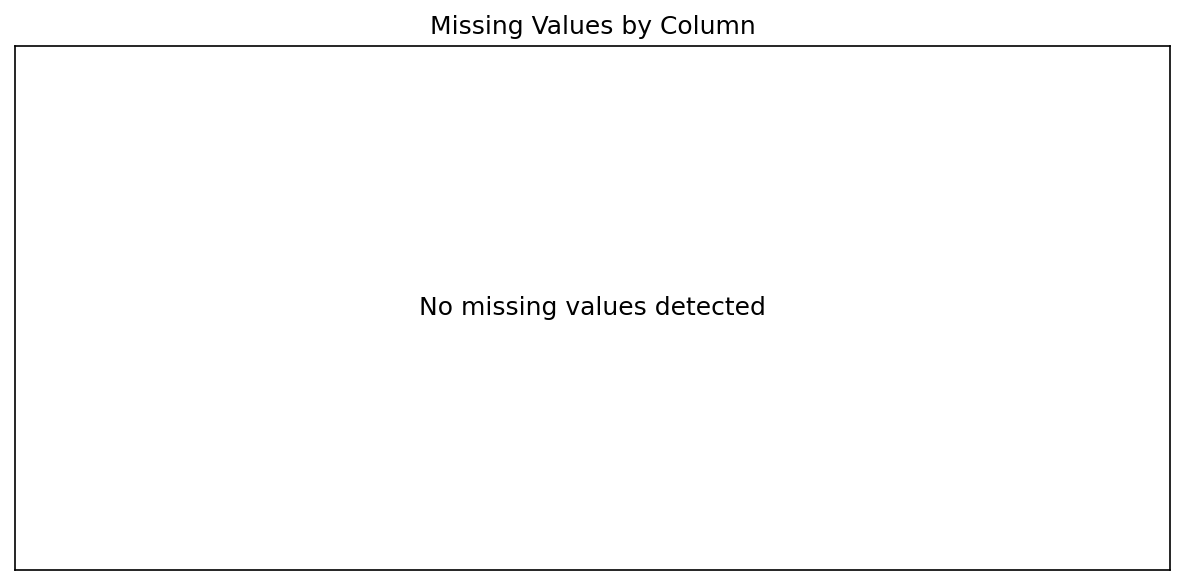

np.int64(0)

In [7]:
path = viz.plot_missing_values(feature_df)
display(Image(filename=path))
feature_df.isnull().sum().sum()

## Feature correlation heatmap

Correlation across all 25 lexical features plus the binary label.

2026-08-07 10:15:45 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/correlation_heatmap.png


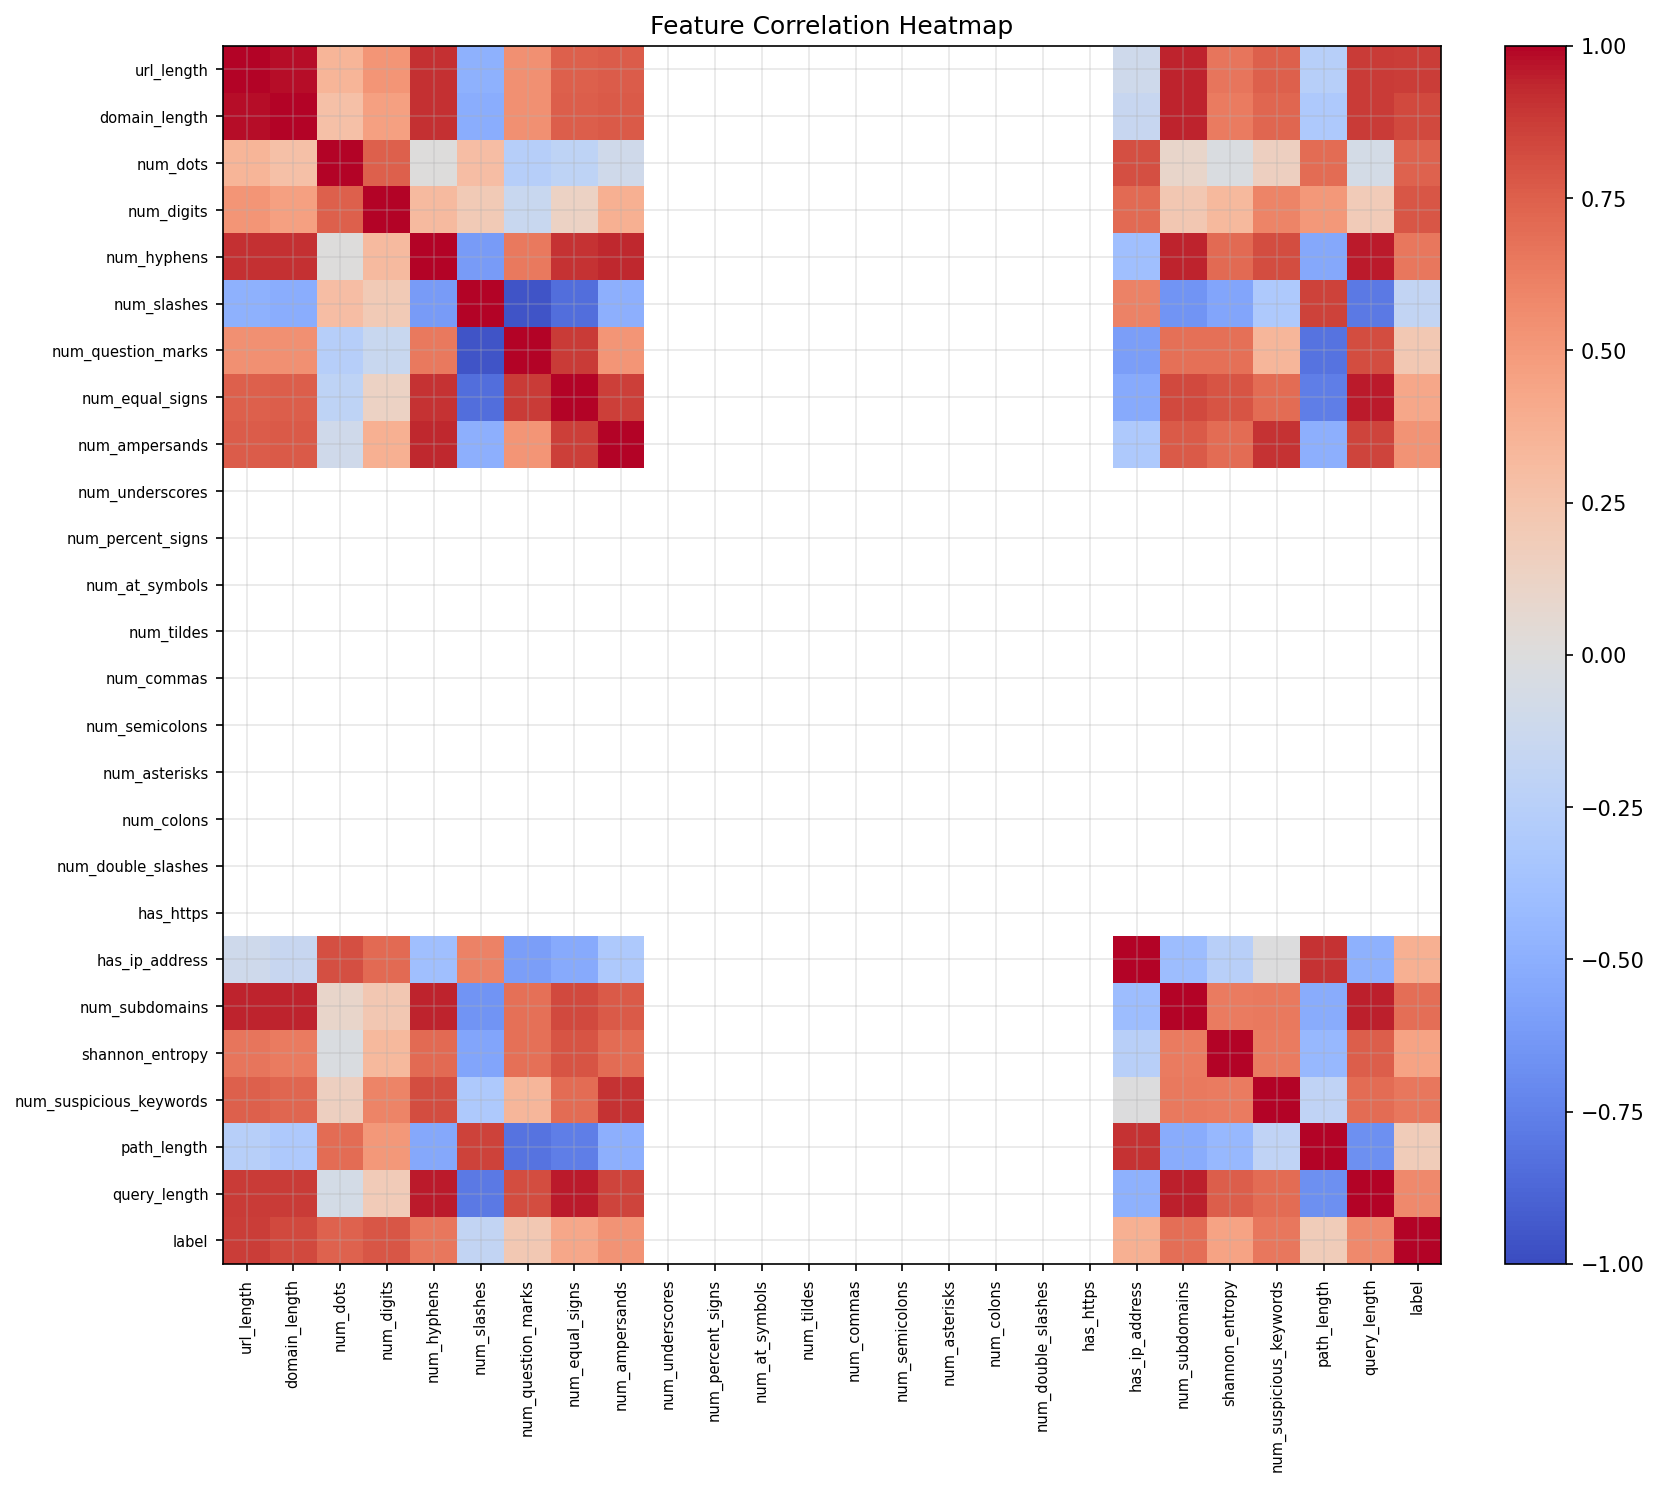

In [8]:
path = viz.plot_correlation_heatmap(feature_df)
display(Image(filename=path))

## Feature importance preview (EDA-stage, correlation-based)

This is a cheap, model-free preview using absolute Pearson correlation with the
label. The rigorous, model-based importance ranking (SHAP) is produced later in
`03_ModelComparison.ipynb` / `src/explainability.py`, once a model has been trained.

2026-08-07 10:15:45 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/feature_importance_preview.png


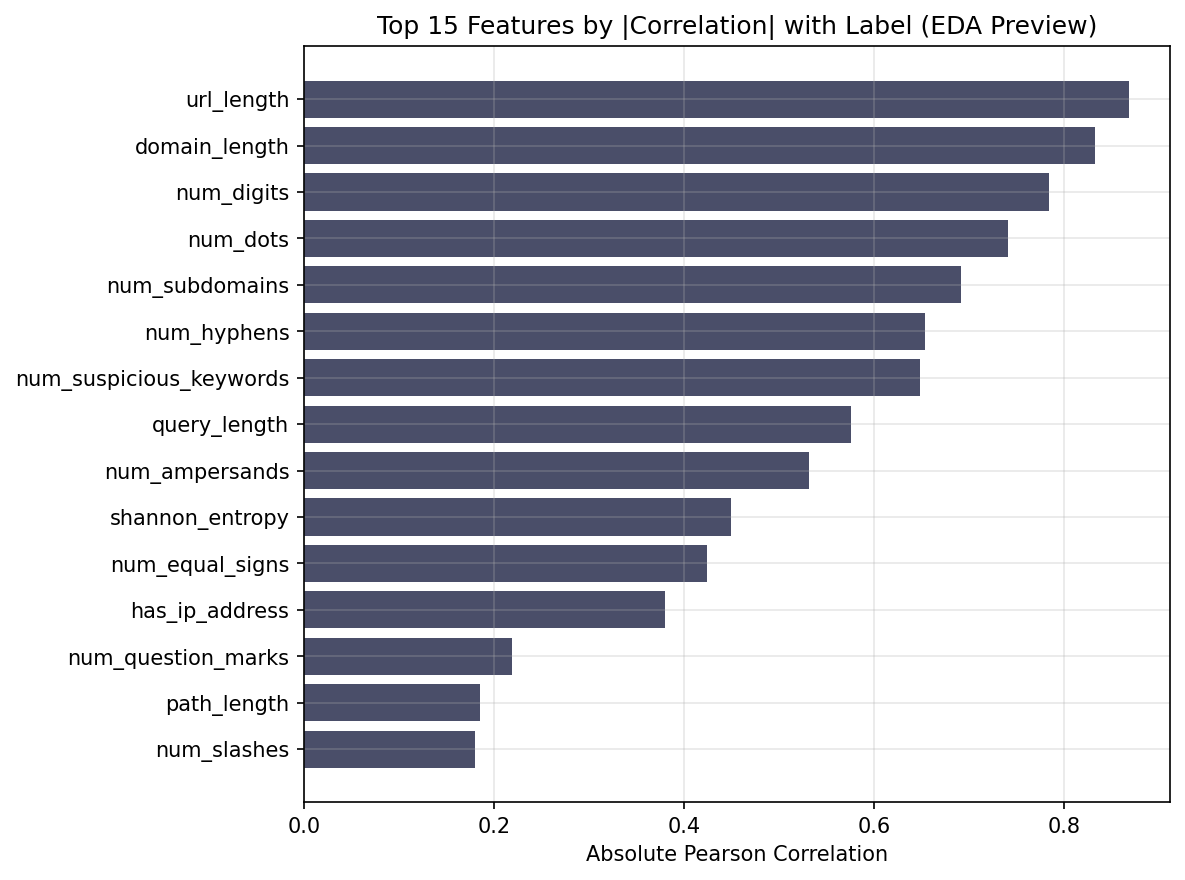

In [9]:
path = viz.plot_feature_importance_preview(feature_df, top_n=15)
display(Image(filename=path))

## Boxplots — feature distributions by class

2026-08-07 10:15:45 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/boxplots.png


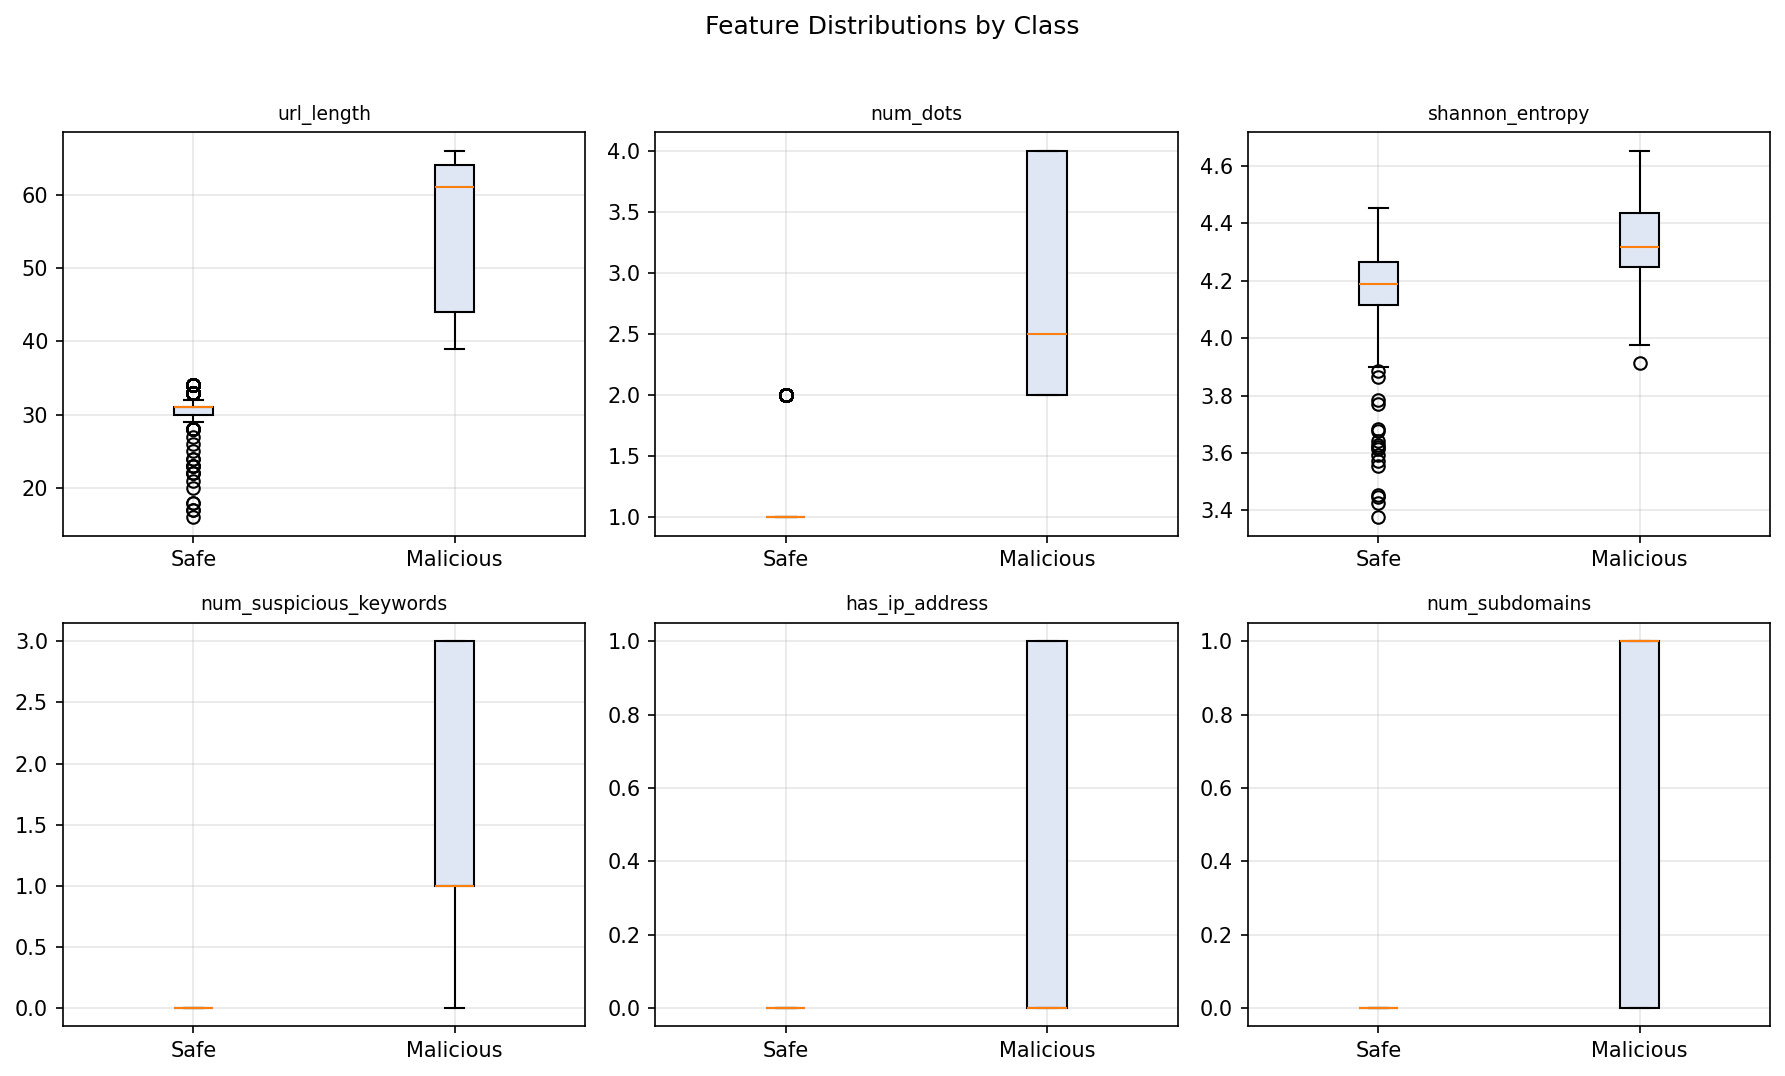

In [10]:
boxplot_features = [
    "url_length", "num_dots", "shannon_entropy",
    "num_suspicious_keywords", "has_ip_address", "num_subdomains",
]
path = viz.plot_boxplots(feature_df, boxplot_features)
display(Image(filename=path))

## Pair plot

Restricted to a handful of the most differentiating features (per the importance
preview above) for readability — a full 25-feature pair plot is not interpretable.

2026-08-07 10:15:46 | INFO     | src.visualization | Saved figure: /home/claude/malicious_url_detector/results/figures/pairplot.png


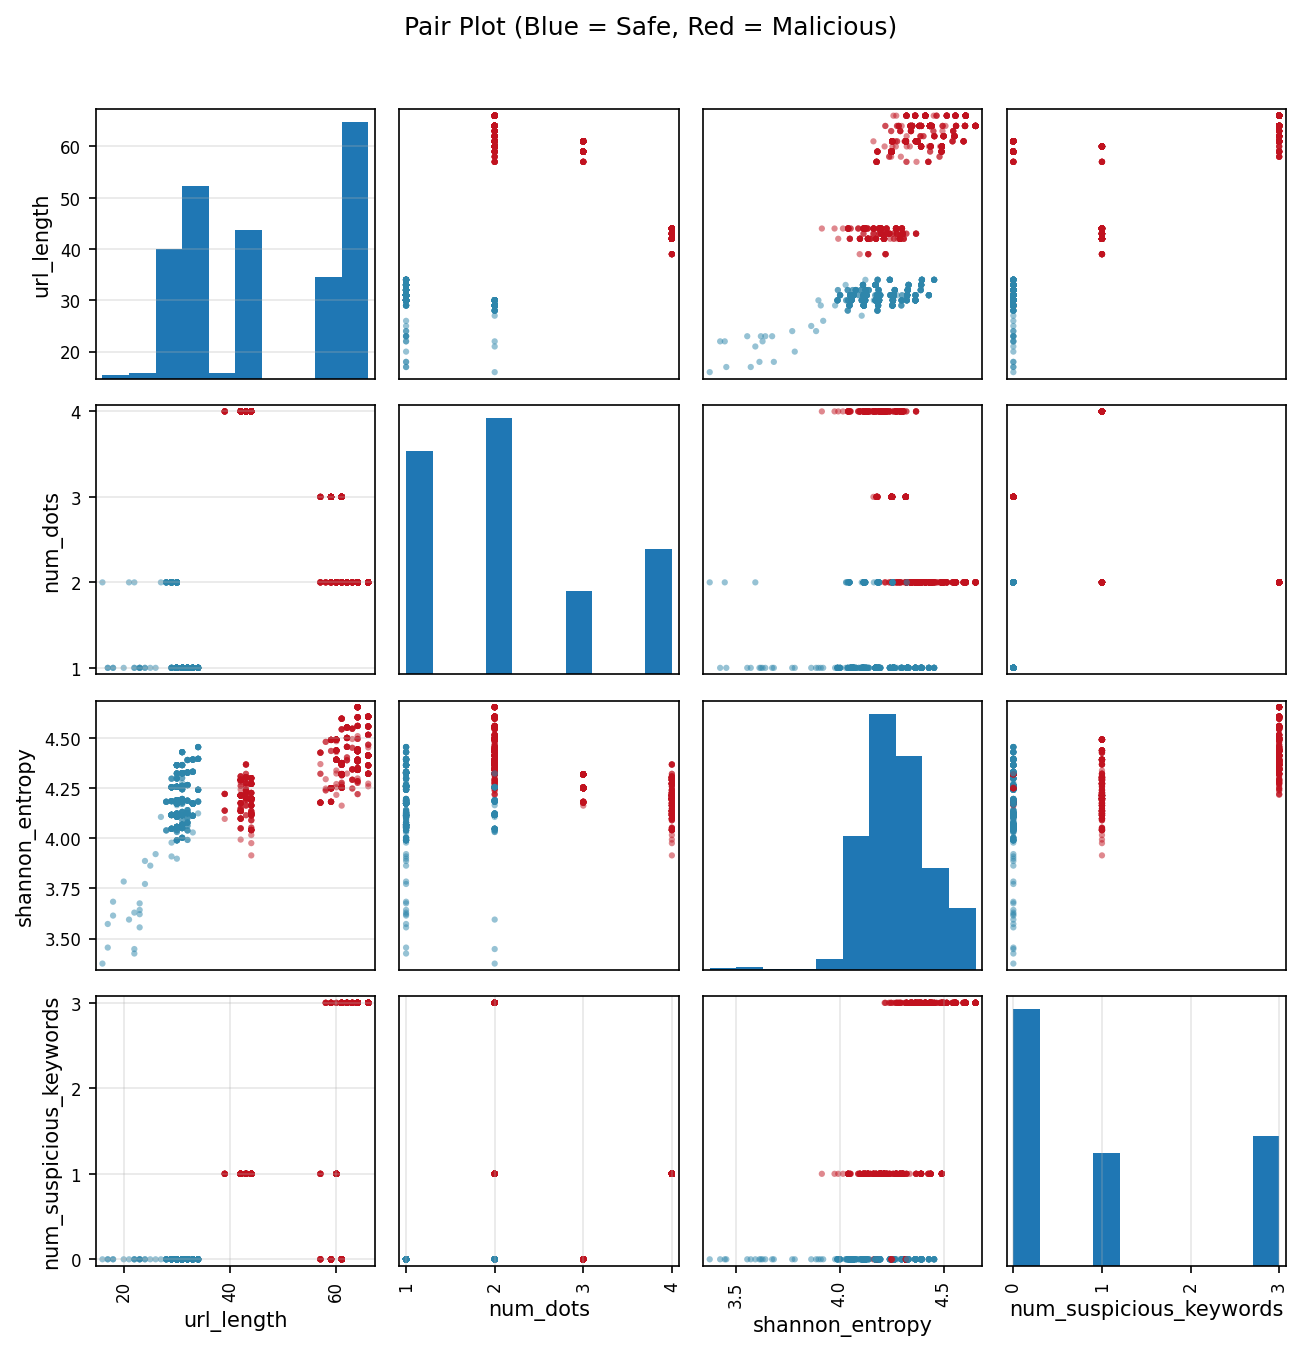

In [11]:
pairplot_features = ["url_length", "num_dots", "shannon_entropy", "num_suspicious_keywords"]
path = viz.plot_pairplot(feature_df, pairplot_features)
display(Image(filename=path))

## Summary statistics

In [12]:
summary_path = viz.save_summary_statistics(feature_df)
summary_df = pd.read_csv(summary_path, index_col=0)
summary_df

2026-08-07 10:15:46 | INFO     | src.visualization | Saved summary statistics: /home/claude/malicious_url_detector/results/metrics/summary_statistics.csv


,count,mean,std,min,25%,50%,75%,max
url_length,1647.0,46.289617,14.503003,16.000,31.000000,44.000000,61.00000,66.000000
domain_length,1647.0,14.554948,3.807390,9.000,11.000000,14.000000,19.00000,19.000000
num_dots,1647.0,2.161506,1.071853,1.000,1.000000,2.000000,3.00000,4.000000
num_digits,1647.0,7.052216,3.953059,0.000,3.000000,6.000000,10.00000,14.000000
num_hyphens,1647.0,0.728597,0.897439,0.000,0.000000,0.000000,2.00000,2.000000
num_slashes,1647.0,3.370978,0.490699,2.000,3.000000,3.000000,4.00000,4.000000
num_question_marks,1647.0,0.614451,0.486873,0.000,0.000000,1.000000,1.00000,1.000000
num_equal_signs,1647.0,0.918033,0.826334,0.000,0.000000,1.000000,2.00000,2.000000
num_ampersands,1647.0,0.303582,0.459944,0.000,0.000000,0.000000,1.00000,1.000000
num_underscores,1647.0,0.000000,0.000000,0.000,0.000000,0.000000,0.00000,0.000000


## Observations

- Class balance and any skew are visible in the class distribution chart above —
  re-check this after loading the real Kaggle dataset, since this notebook run may
  be against a small development/smoke-test sample.
- Highly correlated feature pairs in the heatmap (e.g. features derived from the
  same URL substring, like `num_slashes` and `path_length`) are candidates for
  dimensionality reduction if a future iteration needs a smaller feature set —
  see "Future Improvements" in `README.md`.
- The correlation-based importance preview here is provisional; `03_ModelComparison.ipynb`
  produces the authoritative, model-grounded SHAP importance ranking.

Next: `02_FeatureEngineering.ipynb` walks through each of the 25 lexical feature
extractors individually, including edge-case handling.